# Meta forward model / Parallel ASM / Backpropagation

- parallel prediction is successive. But, Correlation is low at some wavelengths

- PASM 1.1 BP 1.0 
Reconstruction of spatial information before the metasurface is successful.

- PASM 1.1 BP 1.1
Trying to use fft based loss function

- BP 1.11 --> Phase reconstruction w/ propagation between U_obj and U_s2



In [1]:
import sys, os
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import os
from metacam.ops.torch_ops import torch_pad_center, torch_crop_center, NA_to_Circ, return2DGaussian
from metacam.physics.propagation import asm_master_alltorch, circ_mask, torch_fft, torch_ifft
from metacam.data.io import load_mat_file
from metacam.ops.numpy_ops import imcrop_numpy
from skimage import data, color
from pathlib import Path
import torchvision.transforms.functional as TF
from itertools import chain
from metacam.metrics.losses import PSNR, tv_loss, huber_penalty, tv_spk_loss
from metacam.ops.torch_ops import normxcorr2_fft, xcorr2_fft
from IPython.display import clear_output
from metacam.metrics.npcc import NPCCloss
from torchvision.io import read_image
import metacam.vision.phasecam as PF
from metacam.vision.phasecam import load_and_process_speckle_image, plot_tensor_image, plot_images

os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
print("torch:", torch.__version__)
print("mps built:", torch.backends.mps.is_built(), "mps available:", torch.backends.mps.is_available())
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("selected device:", device)
use_antialias = device.type != "mps"
print("interpolate antialias:", use_antialias)


cuda


ERROR:root:ERROR: MATLAB type not supported: function_handle_workspace, (uint32)


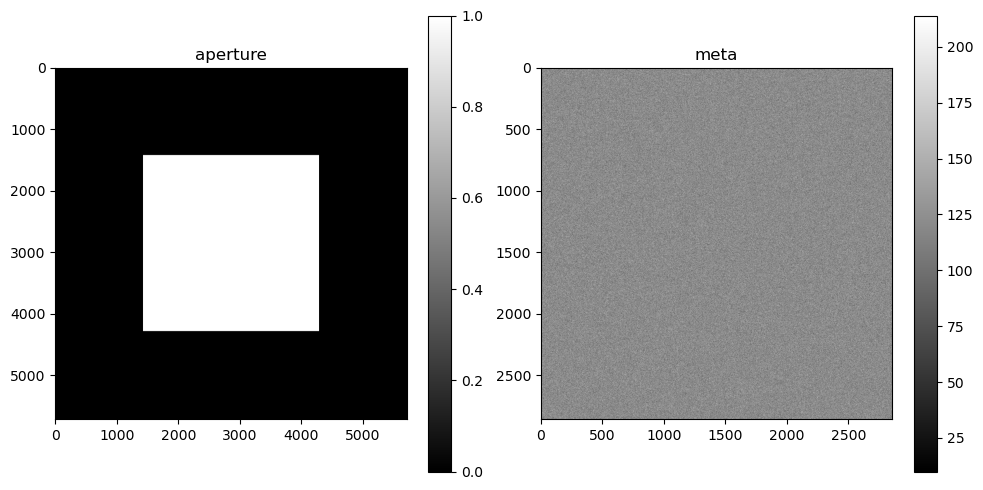

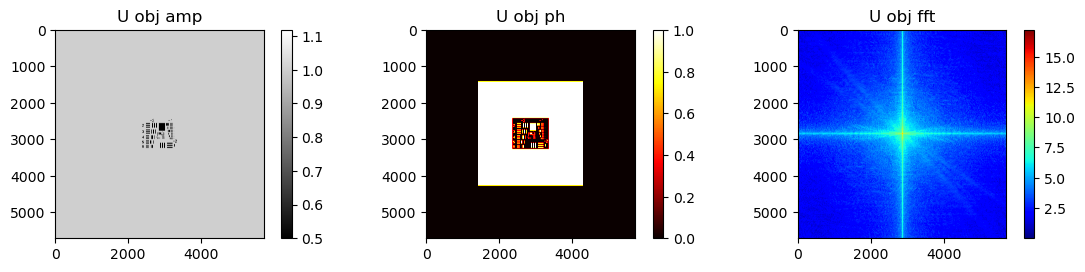

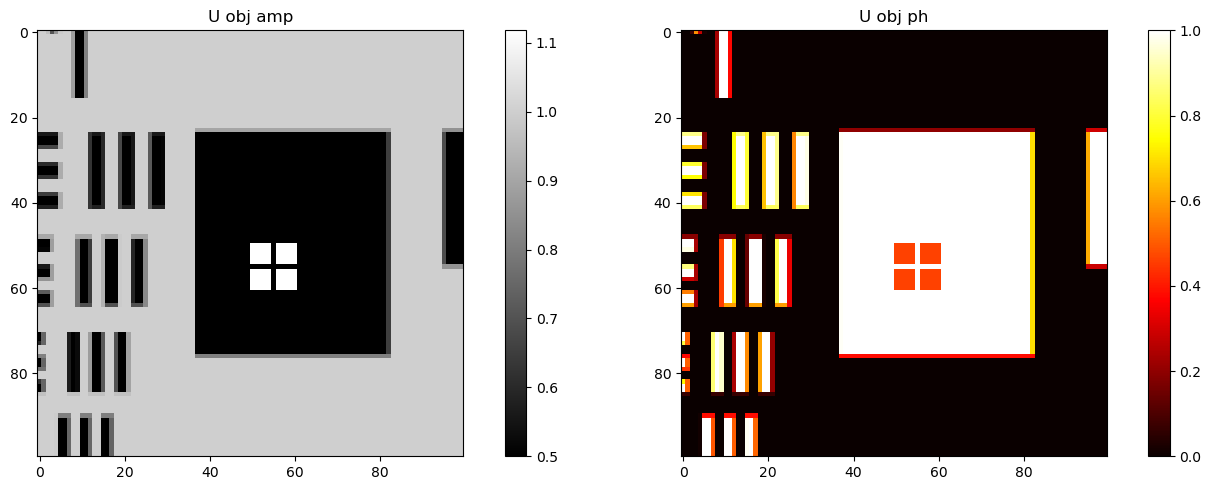

In [2]:
# Units
mm, um, nm = 10 ** (-3), 10 ** (-6), 10 ** (-9)

# Physical parameters
sim_px = 350 * nm
sim_N = 5713
sim_fov = sim_px * sim_N
cam_pp = 1.85 * um
resize_ratio = cam_pp / sim_px
test_wind = 3000

# Define parallel asm module
asmt = asm_master_alltorch(sim_fov, sim_px, device)  # independent to wavelength


# Read meta widthmap - Available NA = 0.3/ 0.6/ 0.75
Fabdata_path = Path("Data") / "Fab" / "B17"
# wmap_file = "0.75NA_random_70_1_300_1mm_mapped_width.mat"
wmap_file = "0.6NA_random_70_1_300_1mm_mapped_width.mat"
wmap_file_dir = Fabdata_path / wmap_file
if not wmap_file_dir.exists():
    raise FileNotFoundError(f"Widthmap file not found: {wmap_file_dir}")
wmapdata = load_mat_file(wmap_file_dir)  # mapped_width
meta_wmap = wmapdata["mapped_width"]

meta_wmap_idx = torch.tensor(meta_wmap - 60, dtype=torch.int, device=device).unsqueeze(0).unsqueeze(0)  # in matlab, 60 --> 59
meta_wmap_idx_1 = meta_wmap_idx

# Define Aperture
aperture_width = 1 * mm
# aperture_width = test_wind * sim_px
aperture_width_px = int(np.fix(aperture_width / sim_px))  # = test_wind

aperture = torch.ones(1, 1, aperture_width_px, aperture_width_px)
aperture = torch_pad_center(aperture, (asmt.ydim, asmt.xdim)).to(device)
aperture_obj = aperture

plt.figure(figsize=(10, 5))
plot_tensor_image(aperture.abs(), subplot_params=(1, 2, 1), title="aperture")
plot_tensor_image(meta_wmap_idx_1.abs(), subplot_params=(1, 2, 2), title="meta")

# Read meta width-phase look-up table
Fabdata_path = Path("Data") / "Fab" / "B17"
LUT_file = "bayesLUT_MSE_v6.3_nonoverlap.mat"
LUT_file_dir = Fabdata_path / LUT_file
if not LUT_file_dir.exists():
    raise FileNotFoundError(f"LUT file not found: {LUT_file_dir}")
LUTdata = load_mat_file(LUT_file_dir)
# MP, lut_opt_interp, wl_calibration_list, wl_interp, wl_list_scan, wl_to_idx
lut_opt_interp = LUTdata["lut_opt_interp"]
ldim = lut_opt_interp.shape[0]
wl_interp = LUTdata["wl_interp"]


def wl_to_idx(wl):
    return np.uint16((wl - 440) * 10)


# Input object
data_name = "Siemens-Star-Focus-Chart.png"
laser_path = Path("Data") / "Target"
data_dir = laser_path / data_name

star = read_image(data_dir)
star = TF.rgb_to_grayscale(star).to(device).unsqueeze(0)
star -= star.min()
star = star / star.max()

# Input object
data_name = "usafimage.png"
laser_path = Path("Data") / "Target"
data_dir = laser_path / data_name

usaf = torch.sum(read_image(data_dir), dim=0)
usaf = usaf.to(device).unsqueeze(0).unsqueeze(0).to(torch.float32)
usaf -= usaf.min()
usaf = usaf / usaf.max()
# usaf = torch.where(usaf<0.99, 0, 1)

ampimg_tensor = usaf * 0.5 + 0.5
ampimg_pad = torch_pad_center(ampimg_tensor, (asmt.ydim, asmt.xdim), padval=1)

phimg_pad = 1 - usaf
phimg_pad = torch_pad_center(phimg_pad, (asmt.ydim, asmt.xdim), padval=1)

U_obj = aperture_obj * ampimg_pad * torch.exp(1j * phimg_pad) + torch.logical_not(aperture_obj)

U_obj[0, 0, sim_N // 2 : sim_N // 2 + 5, sim_N // 2 : sim_N // 2 + 5] = 1 + 0.5j
U_obj[0, 0, sim_N // 2 + 6 : sim_N // 2 + 11, sim_N // 2 : sim_N // 2 + 5] = 1 + 0.5j
U_obj[0, 0, sim_N // 2 : sim_N // 2 + 5, sim_N // 2 + 6 : sim_N // 2 + 11] = 1 + 0.5j
U_obj[0, 0, sim_N // 2 + 6 : sim_N // 2 + 11, sim_N // 2 + 6 : sim_N // 2 + 11] = 1 + 0.5j

plt.figure(figsize=(15, 10))
plot_tensor_image(U_obj.abs(), subplot_params=(4, 4, 1), title="U obj amp")
plot_tensor_image(U_obj.angle(), subplot_params=(4, 4, 2), title="U obj ph", cmap="hot")
plot_tensor_image(torch.log(torch_fft(U_obj).abs()).abs(), subplot_params=(4, 4, 3), title="U obj fft", cmap="jet")

plt.figure(figsize=(15, 5))
plot_tensor_image(torch_crop_center(U_obj, 100).abs(), subplot_params=(1, 2, 1), title="U obj amp")
plot_tensor_image(torch_crop_center(U_obj, 100).angle(), subplot_params=(1, 2, 2), title="U obj ph", cmap="hot")


In [3]:
## Wavelength dependent
wavelength_ref = 532

# Specify wavelength
lut_est = torch.tensor(lut_opt_interp[:, wl_to_idx(wavelength_ref)], dtype=torch.float32, device=device).reshape(1, 1, 1, ldim)

# Calculate meta phasemap
meta_phmap = lut_est.squeeze()[meta_wmap_idx_1]
meta_phmap_simgrid_s2 = torch_pad_center(meta_phmap, (asmt.ydim, asmt.xdim))
U_s1 = aperture * torch.exp(1j * meta_phmap_simgrid_s2)

# Kernels for propagation
z1 = 6.3 * 1e-3  # metasurface to sensor
z2 = 0.4 * 1e-3  # object to metasurface
wl = torch.tensor([[wavelength_ref * nm]]).reshape(1, 1, 1, 1).to(device)
z1 = torch.tensor([z1]).reshape(1, 1, 1, 1).to(device)
z2 = torch.tensor([z2]).reshape(1, 1, 1, 1).to(device)

kz1 = asmt.get_kz(wl)
kernel1 = asmt.get_kernel(wl, kz=kz1, z=z1)
# kernel1_inv = asmt.get_kernel(wl, kz=kz1, z=-z1)

kz2 = asmt.get_kz(wl)
kernel2 = asmt.get_kernel(wl, kz=kz2, z=z2)
kernel2_inv = asmt.get_kernel(wl, kz=kz2, z=-z2)

# Scalable ASM kernels
delta_H, Q_1, Sfov = asmt.sasm_get_kernel(wl=wl, z=z1, BLfactor=0.5)
MASM = Sfov.item() / sim_fov
print(Sfov.item())


0.009576001204550266


Correlation btw ASM and SASM =  0.9152073643627606


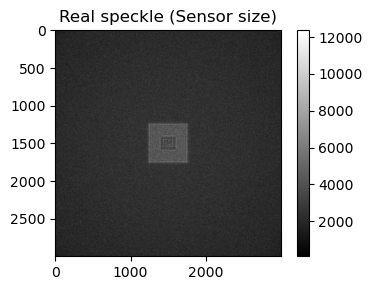

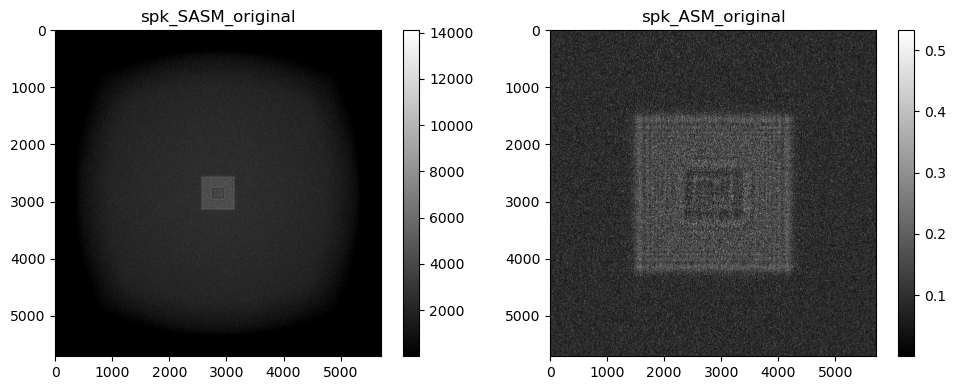

In [4]:
# # Generate simulated speckle,
U_obj_prop = asmt.prop_w_kernel(U=U_obj, ASM_kernel=kernel2) 
U_s1_prop = asmt.sasm_prop_w_kernel(U=U_s1 * U_obj_prop, delta_H=delta_H, Q_1=Q_1)
spk_real = torch.abs(U_s1_prop)
spk_real = F.interpolate(spk_real, scale_factor=1 / (resize_ratio / MASM), mode="bilinear", antialias=use_antialias) 
spk_real = torch_crop_center(spk_real, test_wind)

plt.figure(figsize=(4, 3))
plot_tensor_image(spk_real, subplot_params=(1, 1, 1), title="Real speckle (Sensor size)")


# Compare ASM / SASM
spk_SASM = torch.abs(U_s1_prop)

spk_ASM = asmt.prop_w_kernel(U=U_s1 * U_obj_prop, ASM_kernel=kernel1).abs()
spk_ASM_downsamp = F.interpolate(spk_ASM, scale_factor=1 / (MASM), mode="bilinear", antialias=use_antialias)
 
spk_ASM_downsamp_crop = torch_crop_center(spk_ASM_downsamp, 400)
spk_SASM_crop = torch_crop_center(spk_SASM, 400)

corrmap = normxcorr2_fft(spk_ASM_downsamp_crop.abs(), spk_SASM_crop.abs(), norm=False)
corr = torch.amax(corrmap, dim=(2, 3), keepdim=True)
print("Correlation btw ASM and SASM = ", corr.item())

plt.figure(figsize=(10, 4))
plot_tensor_image(spk_SASM, subplot_params=(1, 2, 1), title="spk_SASM_original") 
plot_tensor_image(spk_ASM, subplot_params=(1, 2, 2), title="spk_ASM_original") 


In [7]:
obj_dim = asmt.xdim
obj_fake = (torch.exp(1j * torch.ones(1, 1, obj_dim, obj_dim).to(device))).detach().clone().requires_grad_(True)

op_obj = optim.Adam([obj_fake], lr=0.05, betas=(0.8, 0.9))

loss_list = []
corr_list = []
num_iterations = 100

criterion_MSE = nn.MSELoss()
criterion_L1 = nn.L1Loss()

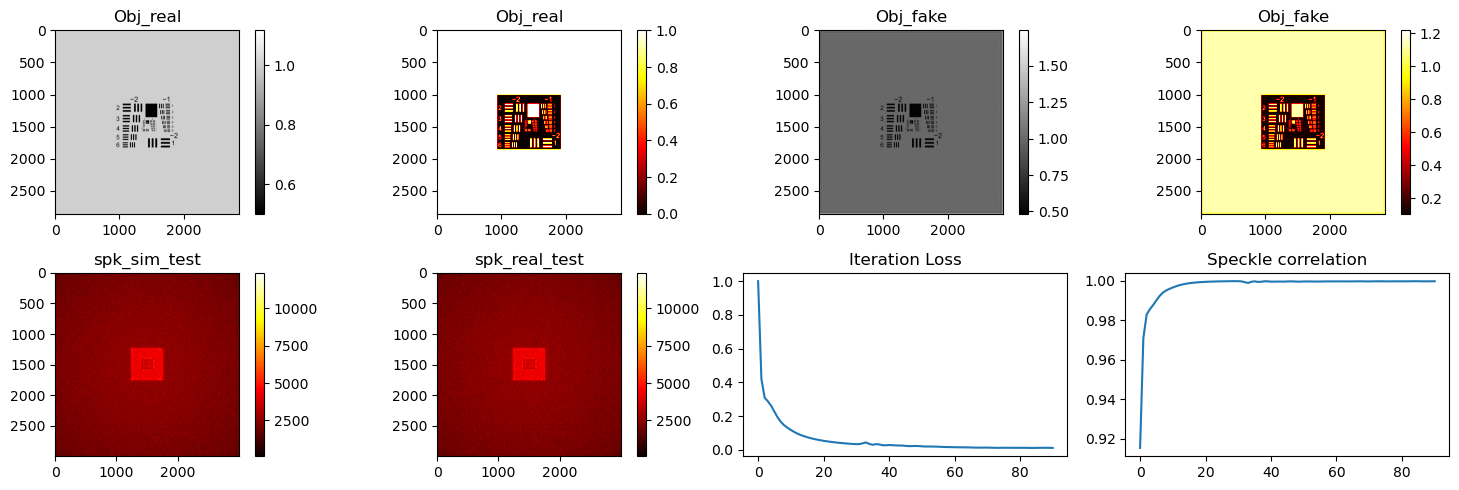

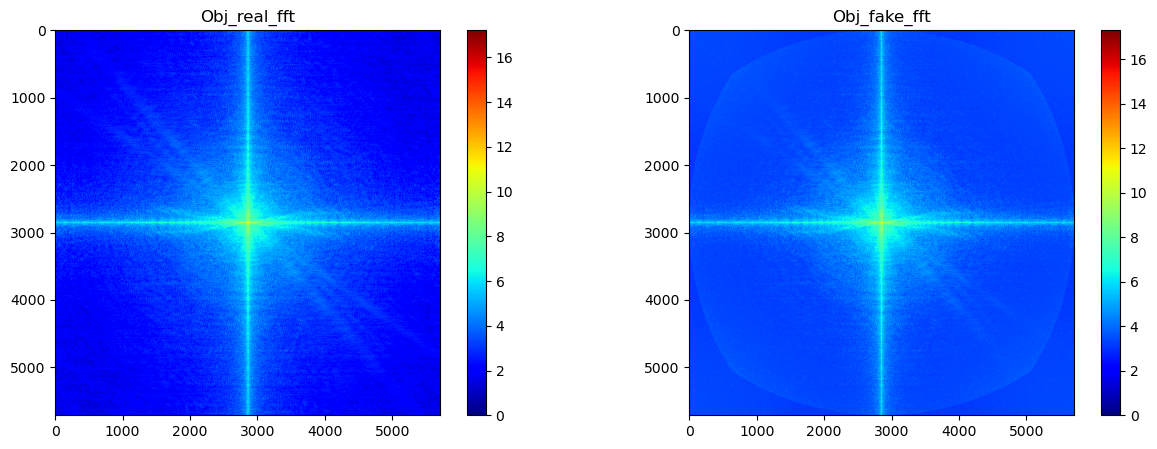

In [8]:
# Training loop
for i in range(num_iterations):
    op_obj.zero_grad()
    # ###############################################################
    U_Obj_fake = torch_pad_center(obj_fake, (asmt.ydim, asmt.xdim), padval=0)
    U_prop = asmt.prop_w_kernel(U=U_Obj_fake, ASM_kernel=kernel2) 
    U_temp = asmt.sasm_prop_w_kernel(U=U_s1 * U_prop, delta_H=delta_H, Q_1=Q_1)

    spk_sim = torch.abs(U_temp)
    spk_sim = F.interpolate(spk_sim, scale_factor=1 / (resize_ratio / MASM), mode="bilinear", antialias=use_antialias)
    spk_sim = torch_crop_center(spk_sim, dim=test_wind) 
    # loss ###############################################################
    corrmap = normxcorr2_fft(spk_sim, spk_real, norm=False)
    corr = torch.amax(corrmap, dim=(2, 3), keepdim=True)
    corr_list.append(corr.item())

    loss_I = criterion_MSE(spk_real, spk_sim)
    
    if i==0:
        loss_I1 = loss_I.detach()    
    
    loss_I = loss_I /loss_I1

    loss_tv = tv_loss(obj_fake, order=1)
    loss = loss_I + loss_tv*0.5 
    loss_list.append(loss.item())
    loss.backward(retain_graph=False)

    op_obj.step()

    # Print progress
    if i % 10 == 0:
        print("----------------------------")
        print(f"Iteration {i}, Spk del Loss: {loss.item()}")

    if i % 10 == 0:
        with torch.no_grad():
            clear_output(wait=True)  # 이전 출력물 지우기
            plt.figure(figsize=(15, 5))

            plh, plw = 2, 4
            plot_tensor_image(torch_crop_center(U_obj, aperture_width_px).abs(), subplot_params=(plh, plw, 1), title="Obj_real", cmap="gray")
            plot_tensor_image(torch_crop_center(U_obj, aperture_width_px).angle(), subplot_params=(plh, plw, 2), title="Obj_real", cmap="hot")
            plot_tensor_image(torch_crop_center(U_Obj_fake, aperture_width_px).abs(), subplot_params=(plh, plw, 3), title="Obj_fake", cmap="gray")
            plot_tensor_image(torch_crop_center(U_Obj_fake, aperture_width_px).angle(), subplot_params=(plh, plw, 4), title="Obj_fake", cmap="hot")

            plot_tensor_image(spk_sim, subplot_params=(plh, plw, 5), title="spk_sim_test", cmap="hot")
            plot_tensor_image(spk_real, subplot_params=(plh, plw, 6), title="spk_real_test", cmap="hot")

            plt.subplot(2, 4, 7), plt.title("Iteration Loss"), plt.plot(loss_list)
            plt.subplot(2, 4, 8), plt.title("Speckle correlation"), plt.plot(corr_list)
            plt.tight_layout()

            plt.figure(figsize=(15, 5))
            plt.subplot(1, 2, 1)
            plt.title("Obj_real_fft")
            dp = torch.log(torch_fft(U_obj).abs())
            plt.imshow(dp[0, 0, :, :].cpu().detach().numpy(), cmap="jet", vmin=0)
            plt.colorbar()

            plt.subplot(1, 2, 2)
            plt.title("Obj_fake_fft")
            dp = torch.log(torch_fft(U_Obj_fake).abs())
            plt.imshow(dp[0, 0, :, :].cpu().detach().numpy(), cmap="jet", vmin=0)
            plt.colorbar()
            plt.show(block=False)


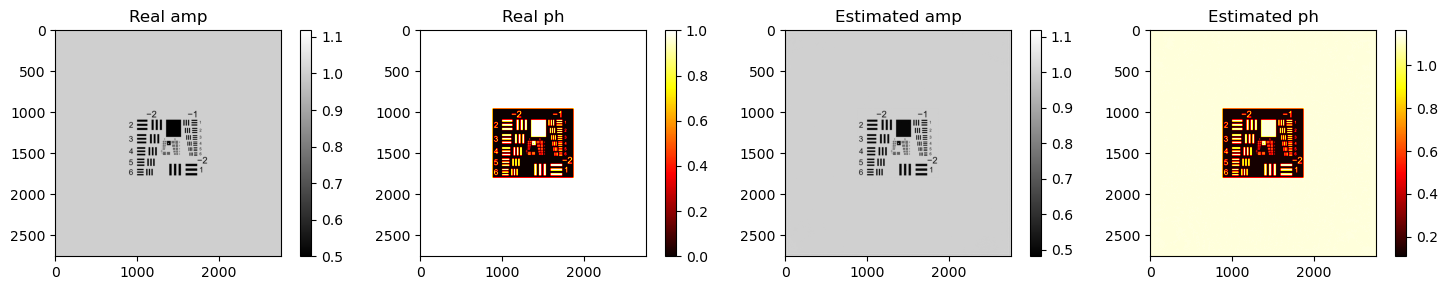

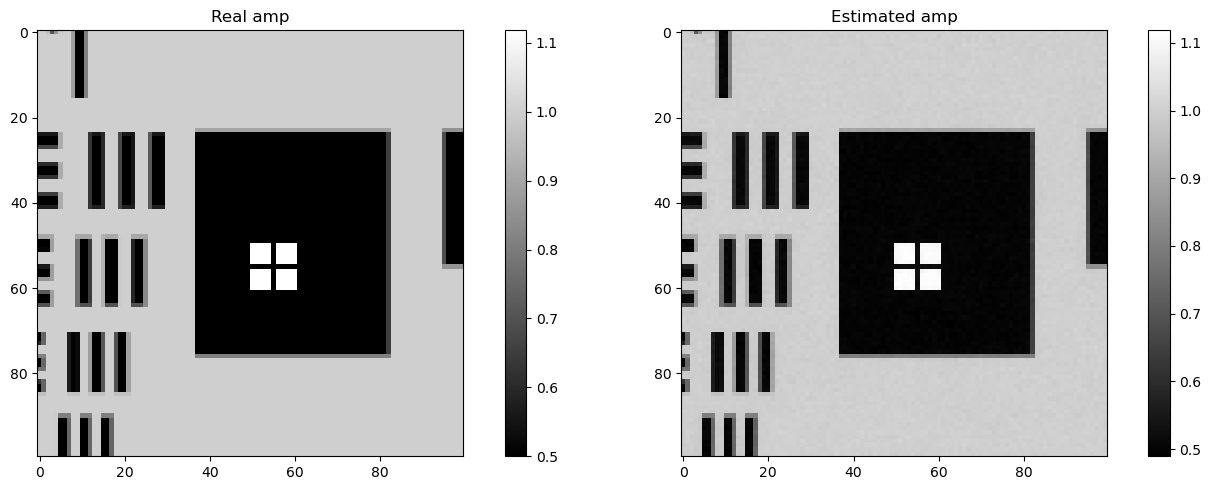

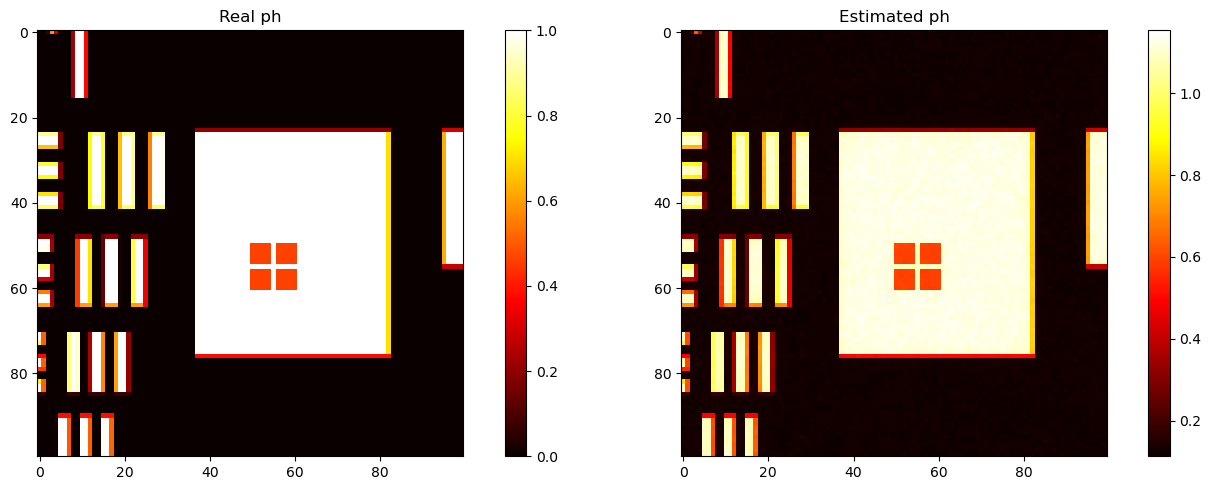

In [9]:
plt.figure(figsize=(15, 3))
plot_tensor_image(torch_crop_center(U_obj, aperture_width_px - 100).abs(), subplot_params=(1, 4, 1), title="Real amp")
plot_tensor_image(torch_crop_center(U_obj, aperture_width_px - 100).angle(), subplot_params=(1, 4, 2), title="Real ph", cmap="hot")  
plot_tensor_image(torch_crop_center(U_Obj_fake, aperture_width_px - 100).abs(), subplot_params=(1, 4, 3), title="Estimated amp")
plot_tensor_image(torch_crop_center(U_Obj_fake, aperture_width_px - 100).angle(), subplot_params=(1, 4, 4), title="Estimated ph", cmap="hot")  

plt.figure(figsize=(15, 5))
plot_tensor_image(torch_crop_center(U_obj, 100).abs(), subplot_params=(1, 2, 1), title="Real amp")
plot_tensor_image(torch_crop_center(U_Obj_fake, 100).abs(), subplot_params=(1, 2, 2), title="Estimated amp")

plt.figure(figsize=(15, 5))
plot_tensor_image(torch_crop_center(U_obj, 100).angle(), subplot_params=(1, 2, 1), title="Real ph", cmap="hot")
plot_tensor_image(torch_crop_center(U_Obj_fake, 100).angle(), subplot_params=(1, 2, 2), title="Estimated ph", cmap="hot")

Maximum values: tensor([[[[0.9998]]]], device='cuda:0', grad_fn=<AmaxBackward0>)
Index of maximum value: (tensor(250, device='cuda:0'), tensor(250, device='cuda:0'))
-0.9997804760932922


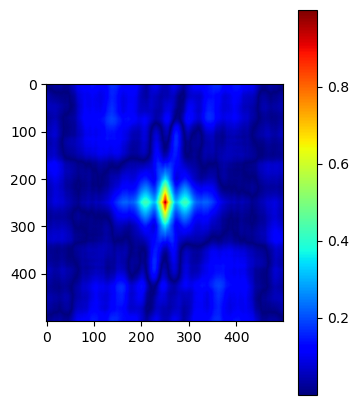

In [10]:
# Initial correlation test
from metacam.ops.torch_ops import normxcorr2_fft

# 크로스 상관 계산
result = normxcorr2_fft(torch_crop_center(U_obj.abs(), 500), torch_crop_center(U_Obj_fake.abs(), 500))

max_val = torch.amax(result, dim=(2, 3), keepdim=True)
max_idx = torch.unravel_index(torch.argmax(result), result.shape[-2:])

print("Maximum values:", max_val)
print("Index of maximum value:", max_idx)

# Visualize the results

plt.figure(figsize=(13, 5))
plt.subplot(1, 3, 1)
plt.imshow(result[0, 0].detach().cpu().numpy(), cmap="jet")
plt.colorbar()


loss_I = NPCCloss(torch_crop_center(U_obj.abs(), 500), torch_crop_center(U_Obj_fake.abs(), 500))
print(loss_I.item())


In [9]:
# torch.index_select(Obj_fake_pad, 0, torch.tensor([1]).to(device))